# Projet Data Science — Segmentation de Transactions Bancaires
**Dataset :** Credit Card Fraud Detection (Kaggle)
**Algorithme :** K-Means Clustering
**Livrable :** Dashboard Streamlit Décisionnel

---

## Cellule 1 — Importation des bibliothèques

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Cellule 2 — Chargement et Exploration des données

In [20]:
# Chargement du dataset
df = pd.read_csv('creditcard.csv')

# Dimensions du dataset
print('=== SHAPE ===')
print(df.shape)

# Aperçu des premières lignes
print('\n=== PREMIÈRES LIGNES ===')
print(df.head())

# Liste des colonnes
print('\n=== COLONNES ===')
print(df.columns.tolist())

# Valeurs manquantes
print('\n=== VALEURS MANQUANTES ===')
print(df.isnull().sum())

# Distribution de la variable cible (fraude vs normal)
print('\n=== DISTRIBUTION FRAUDE ===')
print(df['Class'].value_counts())
print('\nEn pourcentage :')
print(df['Class'].value_counts(normalize=True) * 100)

=== SHAPE ===
(284807, 31)

=== PREMIÈRES LIGNES ===
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.

## Cellule 3 — Preprocessing (Normalisation)

In [21]:
# Copie du dataframe original
df_scaled = df.copy()

# Normalisation de Time et Amount avec StandardScaler
# (V1 à V28 sont déjà normalisées par PCA par Kaggle)
scaler = StandardScaler()
df_scaled['Time'] = scaler.fit_transform(df[['Time']])
df_scaled['Amount'] = scaler.fit_transform(df[['Amount']])

# Suppression de la colonne Class pour le clustering non supervisé
X = df_scaled.drop(columns=['Class'])

print('Données prêtes pour le clustering !')
print(X.shape)

Données prêtes pour le clustering !
(284807, 30)


## Cellule 4 — Méthode du Coude (Choix du k optimal)

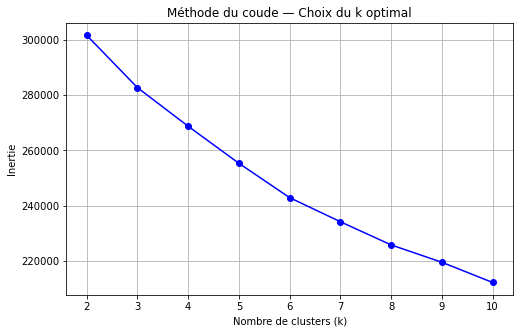

In [22]:
# Échantillon de 10 000 pour accélérer le calcul
X_sample = X.sample(n=10000, random_state=42)

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)

# Visualisation du coude
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude — Choix du k optimal')
plt.grid(True)
plt.show()

# Conclusion : k=3 est optimal (coude visible + interprétable métier)

## Cellule 5 — Clustering K-Means (k=3)

In [23]:
# Application du K-Means avec k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_scaled['Cluster'] = kmeans.fit_predict(X)

print('Clustering terminé !')
print(df_scaled['Cluster'].value_counts())

Clustering terminé !
0    146040
1    132998
2      5769
Name: Cluster, dtype: int64


## Cellule 6 — Analyse et Interprétation des clusters

In [24]:
# On remet la colonne Class pour analyser les clusters
df_scaled['Class'] = df['Class']

# Analyse des clusters : nombre de transactions, montant moyen, fraudes
analyse = df_scaled.groupby('Cluster').agg(
    Nombre_transactions=('Class', 'count'),
    Montant_moyen=('Amount', 'mean'),
    Nb_fraudes=('Class', 'sum'),
    Taux_fraude=('Class', 'mean')
).round(4)

print(analyse)

# Interprétation métier :
# Cluster 0 → Suspects     : montants élevés, taux de fraude 15x supérieur
# Cluster 1 → Normaux Moyens : transactions standard
# Cluster 2 → Normaux Faibles : petites transactions du quotidien

         Nombre_transactions  Montant_moyen  Nb_fraudes  Taux_fraude
Cluster                                                             
0                     146040        -0.1185         225       0.0015
1                     132998        -0.0340         132       0.0010
2                       5769         3.7835         135       0.0234


## Cellule 7 — Visualisation PCA des clusters

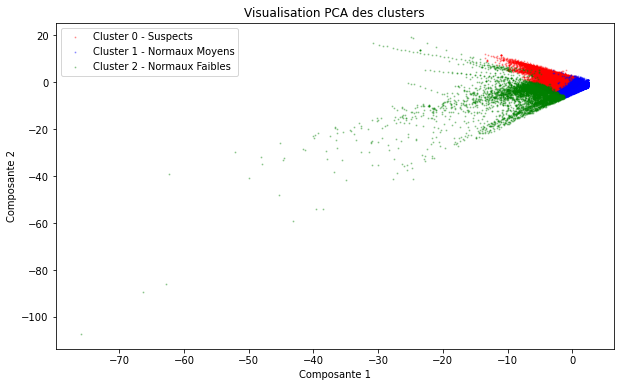

In [25]:
# Réduction à 2 dimensions pour visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Visualisation des 3 clusters
plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green']
labels = ['Cluster 0 - Suspects', 'Cluster 1 - Normaux Moyens', 'Cluster 2 - Normaux Faibles']

for i in range(3):
    mask = df_scaled['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=labels[i], alpha=0.3, s=1)

plt.title('Visualisation PCA des clusters')
plt.xlabel('Composante 1')
plt.ylabel('Composante 2')
plt.legend()
plt.show()

## Cellule 8 — Création du fichier dashboard.py

In [26]:
code = """
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

st.set_page_config(page_title='Dashboard Transactions Bancaires', page_icon='💳', layout='wide')

css = '''
<style>
[data-testid="stAppViewContainer"] { background-color: #1a0a0a; }
[data-testid="stSidebar"] { background-color: #2d1010; border-right: 2px solid #8B0000; }
h1 { color: #e57373 !important; border-bottom: 2px solid #8B0000; padding-bottom: 10px; }
h2, h3 { color: #ef9a9a !important; }
.stMetric { background-color: #2d1010; border-radius: 12px; padding: 15px; border-left: 5px solid #8B0000; }
.stMetric label { color: #ef9a9a !important; }
.stMetric [data-testid="stMetricValue"] { color: #ffffff !important; font-weight: bold; }
p { color: #f5e6e6; }
hr { border-color: #8B0000; }
</style>
'''
st.markdown(css, unsafe_allow_html=True)

@st.cache(allow_output_mutation=True)
def load_and_process():
    df = pd.read_csv('creditcard.csv')
    df_scaled = df.copy()
    scaler = StandardScaler()
    df_scaled['Time'] = scaler.fit_transform(df[['Time']])
    df_scaled['Amount'] = scaler.fit_transform(df[['Amount']])
    X = df_scaled.drop(columns=['Class'])
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_scaled['Cluster'] = kmeans.fit_predict(X)
    df_scaled['Class'] = df['Class']
    df_scaled['Amount_real'] = df['Amount']

    # CORRECTION : on assigne les labels selon le montant moyen
    # Le cluster avec le montant moyen le plus ELEVE = Suspects
    # Le cluster avec le montant moyen le plus BAS = Normaux Faibles
    # Le cluster du milieu = Normaux Moyens
    montant_par_cluster = df_scaled.groupby('Cluster')['Amount_real'].mean()
    ordre = montant_par_cluster.sort_values(ascending=False).index.tolist()
    # ordre[0] = montant le plus haut = Suspects
    # ordre[1] = montant milieu = Normaux Moyens
    # ordre[2] = montant le plus bas = Normaux Faibles
    labels_map = {
        ordre[0]: 'Suspects',
        ordre[1]: 'Normaux Moyens',
        ordre[2]: 'Normaux Faibles'
    }
    df_scaled['Profil'] = df_scaled['Cluster'].map(labels_map)

    return df, df_scaled, X

df, df_scaled, X = load_and_process()

st.sidebar.markdown('<h1 style="color:#e57373;">💳 Dashboard</h1>', unsafe_allow_html=True)
st.sidebar.markdown('<p style="color:#ef9a9a; font-size:0.85rem;">Analyse des Transactions Bancaires</p>', unsafe_allow_html=True)
st.sidebar.markdown('---')

page = st.sidebar.radio('Navigation', [
    '📊 Statistiques Globales',
    '🔍 Exploration des Donnees',
    '🎯 Segmentation',
    '💡 Interpretation Metier'
])

st.sidebar.markdown('---')
st.sidebar.markdown('<p style="color:#e57373; font-weight:bold;">🎛️ Filtres</p>', unsafe_allow_html=True)

type_filter = st.sidebar.selectbox('Type de transaction', ['Tous', 'Normal', 'Fraude'])
cluster_filter = st.sidebar.multiselect(
    'Profil client',
    ['Suspects', 'Normaux Moyens', 'Normaux Faibles'],
    default=['Suspects', 'Normaux Moyens', 'Normaux Faibles']
)
min_amount = float(df['Amount'].min())
max_amount = float(df['Amount'].max())
amount_range = st.sidebar.slider('Montant (EUR)', min_amount, max_amount, (min_amount, max_amount))

df_filtered = df_scaled.copy()
if type_filter == 'Normal':
    df_filtered = df_filtered[df_filtered['Class'] == 0]
elif type_filter == 'Fraude':
    df_filtered = df_filtered[df_filtered['Class'] == 1]
if cluster_filter:
    df_filtered = df_filtered[df_filtered['Profil'].isin(cluster_filter)]
df_filtered = df_filtered[
    (df_filtered['Amount_real'] >= amount_range[0]) &
    (df_filtered['Amount_real'] <= amount_range[1])
]
st.sidebar.markdown(f'<p style="color:#66bb6a; font-weight:bold;">✅ {len(df_filtered):,} transactions</p>', unsafe_allow_html=True)

plt.rcParams['figure.facecolor'] = '#2d1010'
plt.rcParams['axes.facecolor'] = '#3d1515'
plt.rcParams['axes.labelcolor'] = '#ef9a9a'
plt.rcParams['xtick.color'] = '#ef9a9a'
plt.rcParams['ytick.color'] = '#ef9a9a'
plt.rcParams['text.color'] = '#f5e6e6'
plt.rcParams['axes.titlecolor'] = '#e57373'
plt.rcParams['axes.edgecolor'] = '#8B0000'
plt.rcParams['grid.color'] = '#5a2020'

colors_map = {
    'Suspects': '#8B0000',
    'Normaux Moyens': '#C0392B',
    'Normaux Faibles': '#e57373'
}

if page == '📊 Statistiques Globales':
    st.title('📊 Statistiques Globales')
    st.markdown('Vue densemble des transactions bancaires analysees.')
    st.markdown('---')
    col1, col2, col3, col4 = st.columns(4)
    col1.metric('💳 Total Transactions', f'{len(df_filtered):,}')
    col2.metric('💰 Montant Moyen', f"{df_filtered['Amount_real'].mean():.2f} EUR")
    col3.metric('🚨 Fraudes', f"{df_filtered['Class'].sum():,}")
    col4.metric('📈 Taux Fraude', f"{df_filtered['Class'].mean()*100:.2f}%")
    st.markdown('---')
    col1, col2 = st.columns(2)
    with col1:
        st.subheader('Distribution des montants')
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(df_filtered['Amount_real'], bins=100, color='#8B0000', edgecolor='#2d1010', alpha=0.85)
        ax.set_xlabel('Montant (EUR)')
        ax.set_ylabel('Frequence')
        ax.set_title('Distribution des montants')
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)
    with col2:
        st.subheader('Fraude vs Normal')
        fig, ax = plt.subplots(figsize=(8, 4))
        counts = df_filtered['Class'].value_counts().sort_index()
        colors_bar = ['#8B0000' if i == 0 else '#C0392B' for i in counts.index]
        counts.plot(kind='bar', color=colors_bar, ax=ax)
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels(['Normal' if i == 0 else 'Fraude' for i in counts.index], rotation=0)
        ax.set_title('Fraude vs Normal')
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)

elif page == '🔍 Exploration des Donnees':
    st.title('🔍 Exploration des Donnees')
    st.markdown('---')
    st.subheader('Apercu des donnees')
    st.dataframe(df_filtered[['Amount_real', 'Class', 'Profil']].head(100))
    col1, col2 = st.columns(2)
    with col1:
        st.subheader('Statistiques descriptives')
        st.dataframe(df_filtered[['Amount_real', 'Class']].describe())
    with col2:
        st.subheader('Repartition par Profil')
        fig, ax = plt.subplots(figsize=(6, 4))
        profil_counts = df_filtered['Profil'].value_counts()
        colors_pie = ['#8B0000', '#C0392B', '#e57373']
        wedges, texts, autotexts = ax.pie(
            profil_counts, labels=profil_counts.index,
            colors=colors_pie, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': '#2d1010', 'linewidth': 2}
        )
        for t in autotexts:
            t.set_color('white')
        ax.set_title('Repartition des profils')
        st.pyplot(fig)

elif page == '🎯 Segmentation':
    st.title('🎯 Segmentation des Transactions')
    st.markdown('---')
    col1, col2 = st.columns(2)
    with col1:
        st.subheader('Distribution des clusters')
        fig, ax = plt.subplots(figsize=(6, 4))
        profil_counts = df_filtered['Profil'].value_counts()
        colors_list = [colors_map.get(p, '#8B0000') for p in profil_counts.index]
        profil_counts.plot(kind='bar', color=colors_list, ax=ax)
        ax.set_title('Transactions par cluster')
        ax.set_xlabel('Profil')
        ax.set_ylabel('Nombre')
        plt.xticks(rotation=15)
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)
    with col2:
        st.subheader('Montant moyen par cluster')
        fig, ax = plt.subplots(figsize=(6, 4))
        montant_moyen = df_filtered.groupby('Profil')['Amount_real'].mean()
        colors_list2 = [colors_map.get(p, '#8B0000') for p in montant_moyen.index]
        montant_moyen.plot(kind='bar', color=colors_list2, ax=ax)
        ax.set_title('Montant moyen par profil')
        ax.set_ylabel('Montant (EUR)')
        plt.xticks(rotation=15)
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)
    st.subheader('Visualisation PCA des clusters')
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    fig, ax = plt.subplots(figsize=(12, 6))
    for profil, color in colors_map.items():
        mask = df_filtered['Profil'] == profil
        idx = df_filtered[mask].index
        if len(idx) > 0:
            ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, label=profil, alpha=0.3, s=1)
    ax.set_title('Projection PCA des clusters')
    ax.set_xlabel('Composante 1')
    ax.set_ylabel('Composante 2')
    ax.legend(markerscale=8, facecolor='#2d1010', edgecolor='#8B0000')
    ax.grid(True, alpha=0.3)
    st.pyplot(fig)

elif page == '💡 Interpretation Metier':
    st.title('💡 Interpretation Metier')
    st.markdown('---')
    analyse = df_filtered.groupby('Profil').agg(
        Nombre_transactions=('Class', 'count'),
        Montant_moyen=('Amount_real', 'mean'),
        Nb_fraudes=('Class', 'sum'),
        Taux_fraude=('Class', 'mean')
    ).round(4)
    st.subheader('Analyse par profil')
    st.dataframe(analyse)
    col1, col2 = st.columns(2)
    colors_list = [colors_map.get(p, '#8B0000') for p in analyse.index]
    with col1:
        st.subheader('Taux de fraude par cluster')
        fig, ax = plt.subplots(figsize=(6, 4))
        analyse['Taux_fraude'].plot(kind='bar', color=colors_list, ax=ax)
        ax.set_title('Taux de fraude par profil')
        ax.set_ylabel('Taux de fraude')
        plt.xticks(rotation=15)
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)
    with col2:
        st.subheader('Nombre de fraudes par cluster')
        fig, ax = plt.subplots(figsize=(6, 4))
        analyse['Nb_fraudes'].plot(kind='bar', color=colors_list, ax=ax)
        ax.set_title('Nombre de fraudes par profil')
        ax.set_ylabel('Nb fraudes')
        plt.xticks(rotation=15)
        ax.grid(True, alpha=0.3)
        st.pyplot(fig)
    st.markdown('---')
    st.subheader('Recommandations strategiques')
    st.error('🚨 Suspects : Taux de fraude le plus eleve — blocage et verification immediate recommandes')
    st.warning('⚠️ Normaux Moyens : Comportement standard — surveillance periodique suffisante')
    st.success('✅ Normaux Faibles : Tres faible risque — aucune action requise')
"""

import os
path = os.path.join(os.getcwd(), 'dashboard.py')
with open(path, 'w', encoding='utf-8') as f:
    f.write(code)

print("✅ dashboard.py corrigé avec labels fixes !")

✅ dashboard.py corrigé avec labels fixes !


## Cellule 9 — Lancement du Dashboard Streamlit

In [27]:
import subprocess
import sys
import os

dashboard_path = os.path.join(os.getcwd(), 'dashboard.py')

subprocess.Popen([
    sys.executable, '-m', 'streamlit', 'run', dashboard_path
])

print('✅ Streamlit lancé ! Ouvre ton navigateur sur http://localhost:8501')

✅ Streamlit lancé ! Ouvre ton navigateur sur http://localhost:8501
